# Exploit dynamic solvers for variable output scales

For example, consider the numerical solution of a linear ODE with fixed steps:

In [1]:
"""Display the behaviour of the solvers when the scale of the ODE varies."""

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffeqzoo import backend, ivps

from probdiffeq import ivpsolve, probdiffeq

if not backend.has_been_selected:
    backend.select("jax")  # ivp examples in jax

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)

In [2]:
f, u0, (t0, t1), f_args = ivps.affine_independent(initial_values=1.0, a=2.0)


@jax.jit
def vf(y, /, *, t):
    """Evaluate the affine vector field."""
    del t
    return f(y, *f_args)

In [3]:
num_derivatives = 1

tcoeffs = (u0, vf(u0, t=t0))
init, ssm = probdiffeq.ssm_taylor(tcoeffs, ssm_fact="dense")
iwp = probdiffeq.prior_wiener_integrated(ssm=ssm, output_scale=1.0)
ts1 = probdiffeq.constraint_ode_ts1(vf, ssm=ssm)
strategy = probdiffeq.strategy_filter(ssm=ssm)
dynamic = probdiffeq.solver_dynamic(
    strategy=strategy, prior=iwp, constraint=ts1, ssm=ssm
)
mle = probdiffeq.solver_mle(strategy=strategy, prior=iwp, constraint=ts1, ssm=ssm)

In [4]:
t0, t1 = 0.0, 3.0
num_pts = 200

ts = jnp.linspace(t0, t1, num=num_pts, endpoint=True)


solve_dynamic = ivpsolve.solve_fixed_grid(solver=dynamic)
solution_dynamic = jax.jit(solve_dynamic)(init, grid=ts)


solve_mle = ivpsolve.solve_fixed_grid(solver=mle)
solution_mle = jax.jit(solve_mle)(init, grid=ts)

Plot the solution.

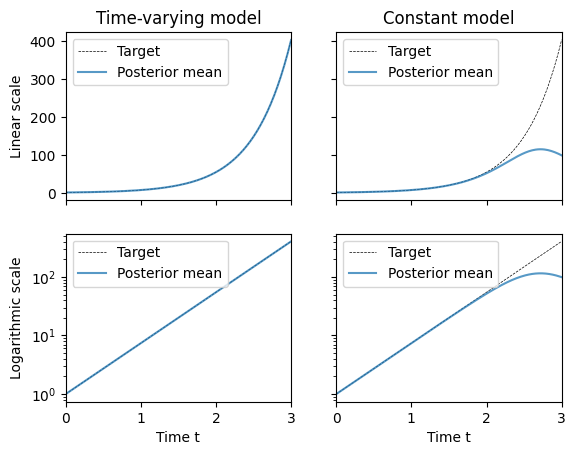

In [5]:
fig, (axes_linear, axes_log) = plt.subplots(ncols=2, nrows=2, sharex=True, sharey="row")


u_dynamic = solution_dynamic.u.mean[0]
u_mle = solution_mle.u.mean[0]

style_target = {
    "marker": "None",
    "label": "Target",
    "color": "black",
    "linewidth": 0.5,
    "alpha": 1,
    "linestyle": "dashed",
}
style_approx = {
    "marker": "None",
    "label": "Posterior mean",
    "color": "C0",
    "linewidth": 1.5,
    "alpha": 0.75,
}


axes_linear[0].set_title("Time-varying model")
axes_linear[0].plot(ts, jnp.exp(ts * 2), **style_target)
axes_linear[0].plot(ts, u_dynamic, **style_approx)
axes_linear[0].legend()

axes_linear[1].set_title("Constant model")
axes_linear[1].plot(ts, jnp.exp(ts * 2), **style_target)
axes_linear[1].plot(ts, u_mle, **style_approx)
axes_linear[1].legend()

axes_linear[0].set_ylabel("Linear scale")

axes_linear[0].set_xlim((t0, t1))


axes_log[0].semilogy(ts, jnp.exp(ts * 2), **style_target)
axes_log[0].semilogy(ts, u_dynamic, **style_approx)
axes_log[0].legend()

axes_log[1].semilogy(ts, jnp.exp(ts * 2), **style_target)
axes_log[1].semilogy(ts, u_mle, **style_approx)
axes_log[1].legend()

axes_log[0].set_ylabel("Logarithmic scale")
axes_log[0].set_xlabel("Time t")
axes_log[1].set_xlabel("Time t")

axes_log[0].set_xlim((t0, t1))

fig.align_ylabels()
plt.show()

The dynamic solver adapts the output-scale so
that both the solution and the output-scale
grow exponentially.
The ODE-solution fits the truth well.

The solver_mle does not have this tool, and
the ODE solution is not able to
follow the exponential: it drifts
back to the origin.
(This is expected, we are basically trying to
fit an exponential with a piecewise polynomial.)